In [1]:
#imports
import os
import random

import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torchvision import models
from torch.utils.data import DataLoader
import torch.optim as optim
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

from src.config import BaseConfig
from src.visualization import Visualizer
from data import load_images, split_data, compute_mean_std, get_test_transform, get_train_transform, ImgDataset
from models import get_resnet18
from train import run_epochs

torch.manual_seed(BaseConfig.SEED)
random.seed(BaseConfig.SEED)

In [2]:
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

## Loading images and creating labels
Labels were mapped to an integer (subsequently in range 0-9) and stored in a dictionary. To make life easier, a reverse dictionary was also implemented.

In [3]:
project_path = os.path.dirname(os.getcwd())
data_path = os.path.join(project_path, 'data')
data, labels, class_to_num = load_images(data_path)
num_to_class = {y:x for x,y in class_to_num.items()}

# Dataset Evaluation
### Sample visualisation
Images vary in quality. Some are digitally written, some are handwritten on a plain background and some are handwritten on a square paper. If images are handwritten, the background appears more gray than white.

All images have the same size (H, W): (130, 160)


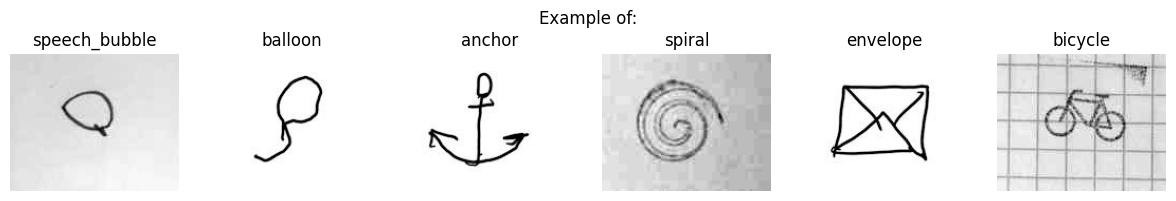

In [4]:
visualizer = Visualizer(data,labels,num_to_class)
visualizer.show_image_size_info()
visualizer.show_images(True, 6)

There are 10 unique classes, displayed below.

In [5]:
print(f"{len(class_to_num)} classes: {list(class_to_num.keys())}")

10 classes: ['anchor', 'balloon', 'bicycle', 'envelope', 'paper_boat', 'peace_symbol', 'smiley', 'speech_bubble', 'spiral', 'thumb']


Data is balanced, although dataset is VERY small - the number of samples for each class is between 41 and 44. One sample is a 2D array of values between 0-255.

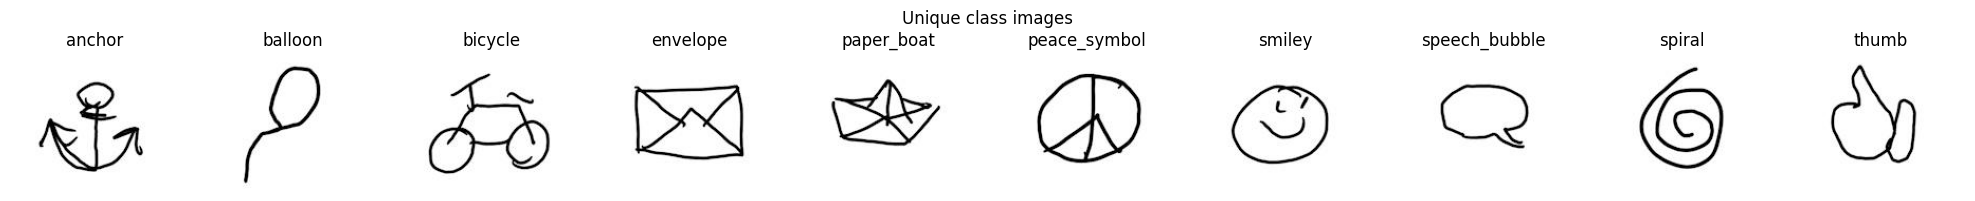

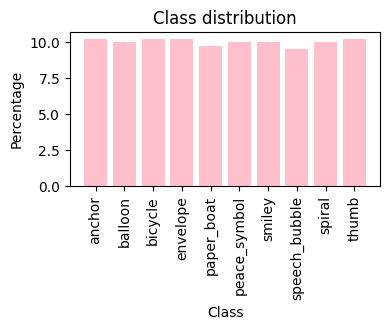

In [6]:
visualizer.show_unique_images()
visualizer.show_class_distribution()

### Laplace variance
Laplace variance is a metric, measuring how blurry an image is. A higher variance means a sharper image, a lower variance means a blurrier image. The distribution has a very high peak around 0, and a smaller, broader peak around 2000-3000. Identifying a threshold is not obvious, so for the sake of this experiment, threshold will be defined by 1000, since no images are observed with this variance. Images with variance lower than threshold are classified as blurry and images with variance higher than threshold as sharp. This threshold is not universal and depends on the dataset.

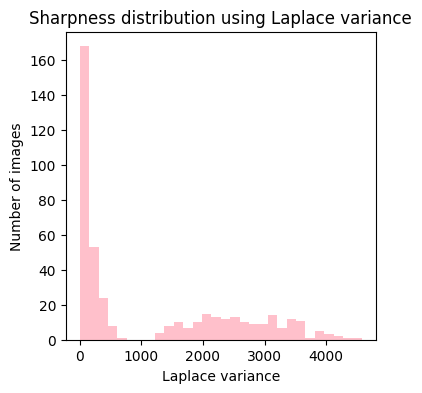

In [7]:
visualizer.show_sharpness_distribution()

### Blurriest vs sharpest image
Laplace variance classified 5 images on the first row as the blurriest and 5 on the second row as the sharpest. This corresponds to what a human would classify as blurry and sharp. The 3 images on the third row are nearest to the threshold, meaning they represent borderline cases between blurry and sharp. They appear sharp visually, so the threshold can be probably slightly increased.

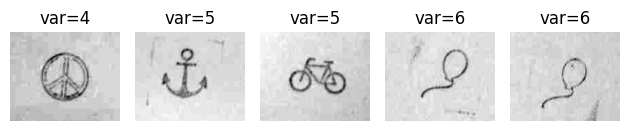

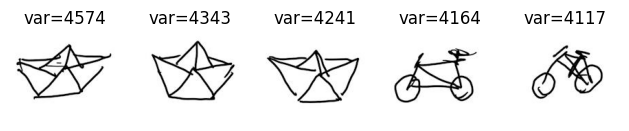

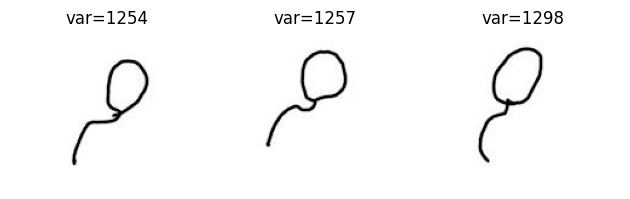

In [8]:
visualizer.show_blurriest_images(5)
visualizer.show_sharpest_images(5)
visualizer.show_images_near_threshold(1000, 3)

### Brightness distribution
The images are in grayscale - the higher pixel value, the lighter pixel is. The mean pixel value in an image can help identify if image is handwritten or digitized - handwritten images could have darker, grayer background. Grid lines can further decrease pixel value, decreasing overall brightness.

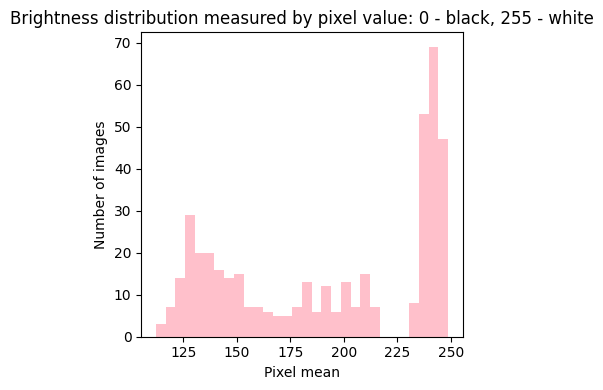

In [9]:
visualizer.show_brightness_distribution()

# Preprocessing

Pipeline:
split to train, test, val --> load to Dataset object --> transformation applied on __getitem__() --> DataLoader batching --> training

Mean and standard deviation need to be calculated on the train set, after distinction of test and validation set, after converting pixel values from 0-255 to 0-1.

In [10]:
X_train, X_val, X_test, y_train, y_val, y_test = split_data(data, labels)
mean, std = compute_mean_std(X_train)

I decided to augment the data with geometric transformations. Color and appearance adjustments aren't appropriate, since the images are in greyscale and are very simple. More aggresive technics, such as cutouts seem also unnecessary.
Only train data will be augmented. The original images are never horizontally flipped, so appplying horizontal flips would introduce orientations that do not appear in test data. Horizontal flipping can only be applied to symmetric data, such as smiley faces and envelopes, where transformation doesn't change the semantic meaning.

### List of classes that can be flipped

In [11]:
flippable_classes = [3,4,5,6,7]
print([num_to_class[x] for x in flippable_classes])

['envelope', 'paper_boat', 'peace_symbol', 'smiley', 'speech_bubble']


# Dataset
Dataset converts input data to torch tensor. Before returning item in __getitem__ it transforms data using previously initialized transforms.

In [12]:
transform_flip = get_train_transform(mean, std, True)
transform_noflip = get_train_transform(mean, std, False)
transform_eval = get_test_transform(mean, std)

test_set = ImgDataset(X_test, y_test, False, transform_eval = transform_eval)
train_set = ImgDataset(X_train, y_train, True, transform_flip=transform_flip, transform_noflip=transform_noflip, flippable_classes=flippable_classes)
val_set = ImgDataset(X_val, y_val, False, transform_eval=transform_eval)

In [13]:
print(flippable_classes)

[3, 4, 5, 6, 7]


In [14]:
print(f"Train/Test/Val:{len(train_set)}/{len(test_set)}/{len(val_set)}")

Train/Test/Val:301/65/65


In [15]:
train_loader  = DataLoader(train_set, batch_size=BaseConfig.BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_set, batch_size=BaseConfig.BATCH_SIZE, shuffle=False)
val_loader = DataLoader(val_set, batch_size=BaseConfig.BATCH_SIZE, shuffle=False)

# Sanity check
Checklist to confirm that data pipeline is correct:
- Pixel value is in range 0-255 (before transforms)
- Data sample is of shape (130, 160) (H, W)
- DataLoader returns batches of shape (16, 3, 130, 160) (B, C, H, W)
- Pixel values are properly normalized after transforms
- Labels match images
- Sample images after transform look visually correct


Minimum pixel value in data[0]: 0
Maximum pixel value in data[0]: 255
Shape of data sample: (130, 160)
Shape of batch sample: torch.Size([16, 3, 130, 160])
Minimum pixel value in image from batch: -3.3411202430725098
Maximum pixel value in image from batch: 0.421135812997818


Text(0.5, 1.0, 'speech_bubble')

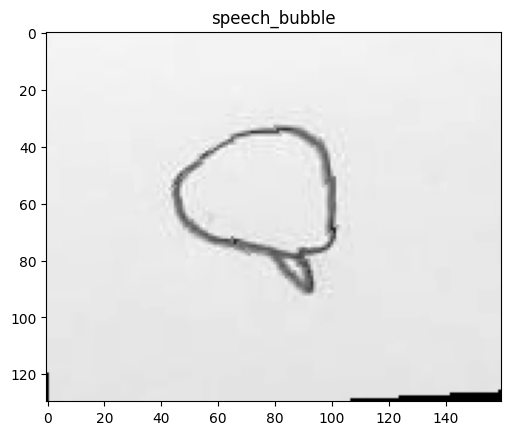

In [16]:
print(f"Minimum pixel value in data[0]: {np.min(data[0])}")
print(f"Maximum pixel value in data[0]: {np.max(data[0])}")
print(f"Shape of data sample: {data[0].shape}")
X, y = next(iter(train_loader))
print(f"Shape of batch sample: {X.shape}")
print(f"Minimum pixel value in image from batch: {torch.min(X[0][0])}")
print(f"Maximum pixel value in image from batch: {torch.max(X[0][0])}")
plt.imshow(X[0][0], cmap='gray')
plt.title(num_to_class[int(y[0])])

# Model
### Question is: Which approach performs better as a feature extraction method for classification on this dataset?
I would suspect, tuning only the last layer will give better performance.

## Retraining the entire model
Results are very good, with validation accuracy reaching 1.0. I don't suspect overfitting, because train and validation accuracy are both very high.

In [17]:
model = get_resnet18(len(class_to_num), False)

model = model.to(device)

criterion = nn.CrossEntropyLoss()

optimizer = optim.SGD(model.parameters(), lr=BaseConfig.LR, momentum=BaseConfig.MOMENTUM)

history = run_epochs(BaseConfig.EPOCHS, train_loader, val_loader, model, optimizer, criterion, device)

Epoch 1/10 | train loss: 2.1977, acc: 0.2193 | val loss: 1.4500, acc: 0.5385
Epoch 2/10 | train loss: 1.1131, acc: 0.7542 | val loss: 0.5271, acc: 0.8462
Epoch 3/10 | train loss: 0.4618, acc: 0.9037 | val loss: 0.1615, acc: 0.9846
Epoch 4/10 | train loss: 0.2419, acc: 0.9701 | val loss: 0.0850, acc: 1.0000
Epoch 5/10 | train loss: 0.1169, acc: 0.9834 | val loss: 0.0502, acc: 1.0000
Epoch 6/10 | train loss: 0.0838, acc: 0.9967 | val loss: 0.0436, acc: 1.0000
Epoch 7/10 | train loss: 0.0809, acc: 0.9934 | val loss: 0.0304, acc: 1.0000
Epoch 8/10 | train loss: 0.0458, acc: 0.9934 | val loss: 0.0217, acc: 1.0000
Epoch 9/10 | train loss: 0.0606, acc: 0.9934 | val loss: 0.0154, acc: 1.0000
Epoch 10/10 | train loss: 0.0399, acc: 1.0000 | val loss: 0.0113, acc: 1.0000


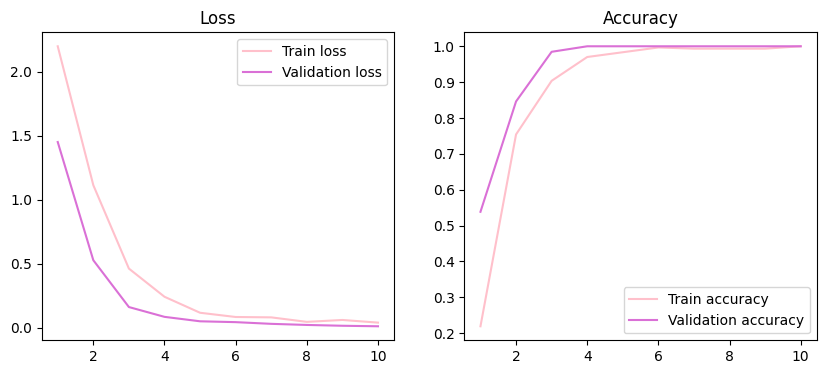

In [18]:
visualizer.show_training_process(history)

Evaluation

## Fine-tuning with frozen backbone
Validation and test acccuracy is about 0.83. I suspect, it's because model is not as flexible as the one retrained fully.

In [21]:
model_fb = get_resnet18(len(class_to_num), True)

model_fb = model_fb.to(device)

criterion_fb = nn.CrossEntropyLoss()

optimizer_fb = optim.SGD(model_fb.fc.parameters(), lr=BaseConfig.LR, momentum=BaseConfig.MOMENTUM)

In [22]:
history = run_epochs(BaseConfig.EPOCHS, train_loader, val_loader, model_fb, optimizer_fb, criterion_fb, device)

Epoch 1/10 | train loss: 2.3285, acc: 0.1595 | val loss: 2.2868, acc: 0.1692
Epoch 2/10 | train loss: 1.9502, acc: 0.3256 | val loss: 1.9852, acc: 0.2615
Epoch 3/10 | train loss: 1.5807, acc: 0.5382 | val loss: 1.6342, acc: 0.4000
Epoch 4/10 | train loss: 1.4078, acc: 0.6013 | val loss: 1.3273, acc: 0.6308
Epoch 5/10 | train loss: 1.2429, acc: 0.6844 | val loss: 1.1825, acc: 0.6000
Epoch 6/10 | train loss: 1.0719, acc: 0.7409 | val loss: 1.0152, acc: 0.8000
Epoch 7/10 | train loss: 1.0693, acc: 0.7010 | val loss: 0.9615, acc: 0.7692
Epoch 8/10 | train loss: 0.9332, acc: 0.7774 | val loss: 0.8656, acc: 0.7538
Epoch 9/10 | train loss: 0.8443, acc: 0.8106 | val loss: 0.8179, acc: 0.8462
Epoch 10/10 | train loss: 0.8357, acc: 0.8073 | val loss: 0.7917, acc: 0.8308


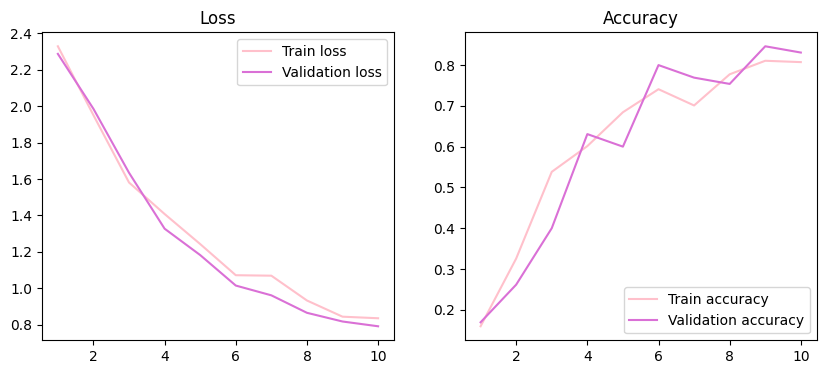

In [23]:
visualizer.show_training_process(history)

# Evaluation
The dataset is balanced and the task is multiclass classification, so for the metric accuracy is chosen.

In [29]:
def run_test(model, loader):
    model.eval()
    all_predictions, all_targets = [], []
    with torch.no_grad():
        for x_batch, y_batch in loader:
            x_batch = x_batch.to(device)
            preds = model(x_batch)
            preds = preds.argmax(1).cpu().numpy()
            all_predictions.append(preds)
            all_targets.append(y_batch.numpy())

    all_predictions = np.concatenate(all_predictions)
    all_targets = np.concatenate(all_targets)
    labels = list(range(10))
    cm = confusion_matrix(all_targets, all_predictions)
    cm_display = ConfusionMatrixDisplay(confusion_matrix=cm)
    cm_display.plot(cmap='RdPu')
    plt.title("Confusion Matrix (MNIST)")
    plt.gca().grid(False)
    plt.show()

    acc = (all_predictions == all_targets).mean()
    print(f"Test accuracy: {np.round(acc,4)}")

### Fine-tuned model

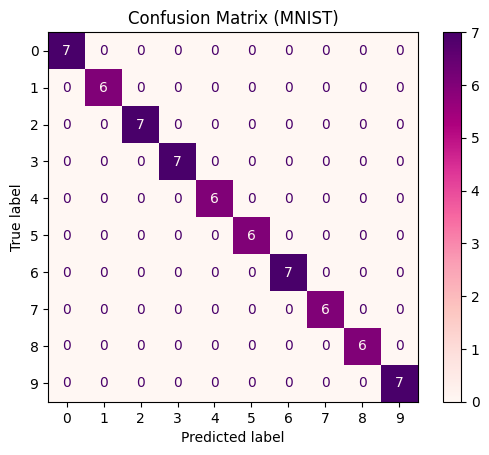

Test accuracy: 1.0


In [30]:
run_test(model, test_loader)

### Model with last layer retrained

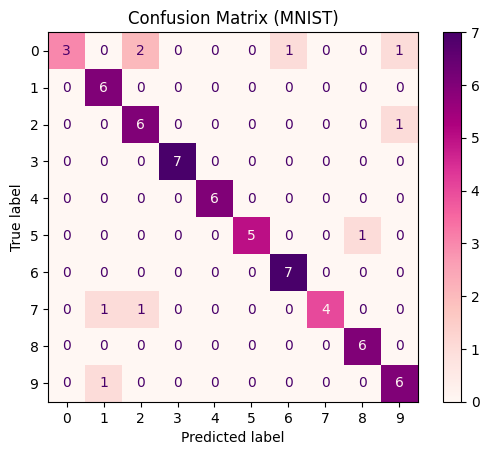

Test accuracy: 0.8615


In [31]:
run_test(model_fb,test_loader)